# Data Cleaning — `Tourist_Accommodation`

Limpieza de la tabla `Tourist_Accommodation` importada desde MySQL, partiendo de las conclusiones del EDA (`EDA_29_06_2026.ipynb y Data_Understanding_29_06_2026.pdf`).

**Puntos que se cubren:**
1. Corrección de tipos de datos
2. Eliminación o corrección de duplicados
3. Tratamiento de valores faltantes
4. Validación y corrección de valores atípicos
5. Estandarización de formatos

**Salida final:** un único CSV limpio (`../Data/clean_dataset_29_06_2026.csv`) sobre el que se aplicará la fase de *Data Transformation*.

> **Alcance de esta fase.** Aquí solo se limpia y se corrigen tipos/formatos. **NO** se hacen aquí (van en *Transformation*):
> - Reescalado de reseñas/puntuaciones: `review_scores_rating` 0–1000 → 0–100 y sub-puntuaciones 0–100 → 0–10 (lo hace Dídac).
> - Paso de `is_instant_bookable` a 0/1.
>
> No se elimina información salvo lo estrictamente necesario (versiones antiguas de un mismo alojamiento).

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import mysql.connector
from pathlib import Path
from getpass import getpass

pd.set_option('display.max_columns', None)

In [5]:
df = pd.read_csv(r"C:\Users\lacal\Desktop\IT_ACADEMY\simulador\ProjecteData\Equip_34\Data\raw_dataset_06_07_2026.csv")

In [6]:
df

,apartment_id,name,description,host_id,neighbourhood_name,neighbourhood_district,room_type,accommodates,bathrooms,bedrooms,beds,amenities_list,price,minimum_nights,maximum_nights,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,first_review_date,last_review_date,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,is_instant_bookable,reviews_per_month,country,city,insert_date
0,11964,A ROOM WITH A VIEW,Private bedroom in our attic apartment. Right ...,45553,Centro,NaN,Private room,2,2.0,1.0,1.0,"TV,Internet,Wifi,Air conditioning,Elevator,Buz...",400.0,3,365,VERDADERO,7,20,40,130,78,02/01/2010,05/09/2017,970.0,100.0,100.0,100.0,100.0,100.0,100.0,FALSO,75.0,spain,malaga,31/07/2018
1,21853,Bright and airy room,We have a quiet and sunny room with a good vie...,83531,C�rmenes,Latina,Private room,1,1.0,1.0,1.0,"TV,Internet,Wifi,Air conditioning,Kitchen,Free...",170.0,4,40,VERDADERO,0,0,0,162,33,10/10/2014,15/07/2018,920.0,90.0,90.0,100.0,100.0,80.0,90.0,FALSO,52.0,spain,madrid,10/01/2020
2,32347,Explore Cultural Sights from a Family-Friendly...,Open French doors and step onto a plant-filled...,139939,San Vicente,Casco Antiguo,Entire home/apt,4,1.0,2.0,2.0,"TV,Internet,Wifi,Air conditioning,Wheelchair a...",990.0,2,120,VERDADERO,26,31,31,270,148,05/01/2011,22/07/2019,980.0,100.0,100.0,100.0,100.0,100.0,100.0,VERDADERO,142.0,spain,sevilla,29/07/2019
3,35379,Double 02 CasanovaRooms Barcelona,Room at a my apartment. Kitchen and 2 bathroom...,152232,l'Antiga Esquerra de l'Eixample,Eixample,Private room,2,2.0,1.0,1.0,"TV,Internet,Wifi,Kitchen,Breakfast,Elevator,Bu...",400.0,2,730,VERDADERO,9,23,49,300,292,13/03/2012,04/01/2020,940.0,100.0,90.0,100.0,100.0,100.0,90.0,VERDADERO,306.0,spain,barcelona,10/01/2020
4,35801,Can Torras Farmhouse Studio Suite,Lay in bed & watch sunlight change the mood of...,153805,Quart,NaN,Private room,5,1.0,2.0,5.0,"Wifi,Pool,Free parking on premises,Breakfast,P...",900.0,1,180,VERDADERO,0,19,49,312,36,08/07/2011,08/08/2018,970.0,100.0,100.0,100.0,100.0,100.0,100.0,FALSO,39.0,spain,girona,19/02/2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,32392193,Espectacular habitaci�n,NaN,238089984,Sant Antoni,Eixample,Private room,1,1.0,1.0,1.0,"TV,Wifi,Elevator,Heating,Washer,Essentials,Sha...",3000.0,32,1125,VERDADERO,28,58,88,363,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,VERDADERO,NaN,spain,barcelona,16/10/2019
7996,32392774,? Tu Hogar de Lujo ????? en el Centro de Sevilla,"Exclusivo, amplio y luminoso alojamiento situa...",243246681,Arenal,Casco Antiguo,Entire home/apt,6,2.0,3.0,4.0,"Patio or balcony, Long term stays allowed, Sha...",2090.0,2,60,VERDADERO,0,11,41,41,36,17/03/2019,09/09/2020,1000.0,100.0,100.0,100.0,100.0,100.0,100.0,FALSO,157.0,spain,sevilla,31/01/2021
7997,32395123,Rooms by G Bella Mar�a 3,The 2-star Bella Maria has 24-hourreception an...,159933359,Felanitx,NaN,Entire home/apt,2,1.0,1.0,2.0,"Air conditioning,Pool,Kitchen,Free parking on ...",930.0,1,1125,VERDADERO,23,53,83,184,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,VERDADERO,NaN,spain,mallorca,24/04/2019
7998,32407332,LUMINOSO Y ENCANTADOR PISO CERCA DE TODO,PISO MUY ILUMINADO CON UNA TERRAZA ESTUPENDA C...,187631805,Proven�als del Poblenou,Sant Mart�,Private room,3,2.0,2.0,2.0,"TV,Wifi,Air conditioning,Kitchen,Free parking ...",960.0,2,15,VERDADERO,1,17,40,315,21,04/03/2019,28/07/2019,980.0,100.0,100.0,100.0,100.0,100.0,100.0,VERDADERO,389.0,spain,barcelona,12/08/2019


In [7]:
# Copia de trabajo para no alterar el DataFrame original importado
df_clean = df.copy()

## 1. Corrección de tipos de datos

- `bathrooms`,`beds`  y `bedrooms` llegan como `float64` aunque son recuentos → a entero nullable (`Int64`, admite nulos).
- Fechas (`first_review_date`, `last_review_date`, `insert_date`) están como texto `dd/mm/aaaa` → a `datetime`.


In [8]:
# --- Recuentos que venían como texto -> entero nullable (Int64) ---
count_cols = ['bathrooms', 'bedrooms', 'beds']
for col in count_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').astype('Int64')

# --- Fechas dd/mm/aaaa -> datetime ---
date_cols = ['first_review_date', 'last_review_date', 'insert_date']
for col in date_cols:
    df_clean[col] = pd.to_datetime(df_clean[col], format='%d/%m/%Y', errors='coerce')

df_clean[count_cols + date_cols].dtypes

bathrooms                     Int64
bedrooms                      Int64
beds                          Int64
first_review_date    datetime64[ns]
last_review_date     datetime64[ns]
insert_date          datetime64[ns]
dtype: object

In [9]:
# Comprobación: la conversión no debe crear nulos "nuevos" inesperados
print("Nulos tras convertir tipos (deben coincidir con los originales):")
for col in count_cols + date_cols:
    print(f"  {col:20s} nulos: {df_clean[col].isna().sum():5d}  |  original: {df[col].isna().sum()}")

Nulos tras convertir tipos (deben coincidir con los originales):
  bathrooms            nulos:    43  |  original: 43
  bedrooms             nulos:    39  |  original: 39
  beds                 nulos:     8  |  original: 8
  first_review_date    nulos:  1614  |  original: 1614
  last_review_date     nulos:  1615  |  original: 1615
  insert_date          nulos:     0  |  original: 0


## 2. Eliminación o corrección de duplicados

No hay filas completamente idénticas, pero sí `apartment_id` repetidos: el mismo alojamiento volcado en fechas distintas. Se conserva únicamente la **última foto** (máximo `insert_date`) de cada `apartment_id`.

In [10]:
# Filas 100% duplicadas
print("Filas completamente duplicadas:", df_clean.duplicated().sum())

# apartment_id repetidos (mismo alojamiento en distintos volcados)
rep = df_clean['apartment_id'].value_counts()
rep = rep[rep > 1]
print(f"apartment_id repetidos: {rep.shape[0]}  (filas implicadas: {int(rep.sum())})")
print("Fecha global mas reciente de volcado (insert_date):", df_clean['insert_date'].max().date())

# Nos quedamos con el registro de mayor insert_date por apartment_id
antes = len(df_clean)
df_clean = (
    df_clean.sort_values('insert_date')
            .drop_duplicates(subset='apartment_id', keep='last')
            .reset_index(drop=True)
)
print(f"\nRegistros eliminados (versiones antiguas): {antes - len(df_clean)}")
print("Dimensiones tras deduplicar:", df_clean.shape)
print("apartment_id unico ahora?", df_clean['apartment_id'].is_unique)

Filas completamente duplicadas: 0
apartment_id repetidos: 299  (filas implicadas: 606)
Fecha global mas reciente de volcado (insert_date): 2021-02-27

Registros eliminados (versiones antiguas): 307
Dimensiones tras deduplicar: (7693, 35)
apartment_id unico ahora? True


## 3. Tratamiento de valores faltantes

Se **conservan** los registros con nulos (no se eliminan) y **no se imputan** valores que puedan sesgar los análisis posteriores:

- `review_scores_*`, `first_review_date`, `last_review_date`, `reviews_per_month`: nulos **estructurales** = alojamientos sin reseñas (`number_of_reviews = 0`). Se dejan como nulos.
- `has_availability`: solo `VERDADERO` + nulos (no hay `FALSO`); los nulos se dejan como desconocido (no se convierten a falso). En este caso se creara columna de `has_availability`con valores 1 y 0 respetando los nulos
- `neighbourhood_district`, `price`, `bathrooms`, `bedrooms`, `beds`, `name`, `description`: se conservan sin imputar.

*(Si en Transformation se decide imputar `price` o tratar `has_availability`, se hará allí con criterio de negocio.)*

In [25]:
# Panorama de nulos tras deduplicar
nulos = pd.DataFrame({
    "nulos": df_clean.isnull().sum(),
    "%": (df_clean.isnull().mean() * 100).round(2)
})
nulos[nulos["nulos"] > 0].sort_values("%", ascending=False)

,nulos,%
neighbourhood_district,3024,39.31
review_scores_value,1649,21.44
review_scores_location,1649,21.44
review_scores_checkin,1648,21.42
review_scores_accuracy,1643,21.36
review_scores_communication,1639,21.31
review_scores_cleanliness,1637,21.28
review_scores_rating,1634,21.24
last_review_date,1555,20.21
first_review_date,1554,20.20


In [26]:
# Los nulos de valoraciones son estructurales: alojamientos sin reseñas
sin_reviews = df_clean['number_of_reviews'] == 0
print("Alojamientos con number_of_reviews == 0 :", sin_reviews.sum())
print("  de ellos con review_scores_rating nulo:", (sin_reviews & df_clean['review_scores_rating'].isna()).sum())
print("Con reseñas (>0) pero rating nulo (nulo real, no estructural):",
      ((~sin_reviews) & df_clean['review_scores_rating'].isna()).sum())

print("\nhas_availability (solo VERDADERO + nulos, sin FALSO):")
print(df_clean['has_availability'].value_counts(dropna=False))

Alojamientos con number_of_reviews == 0 : 1551
  de ellos con review_scores_rating nulo: 1551
Con reseñas (>0) pero rating nulo (nulo real, no estructural): 83

has_availability (solo VERDADERO + nulos, sin FALSO):
has_availability
VERDADERO    7159
NaN           534
Name: count, dtype: int64


In [27]:
# utilizamos Int64 para poder tener nulos en la columna numérica y obtener un tipo de dato entero, en lugar de float que es lo que obtendríamos con int64.
df['has_availability_numeric'] = df['has_availability'].map({'VERDADERO': 1, 'FALSO': 0}).astype('Int64')

print(df['has_availability_numeric'].value_counts(dropna=False))
print(df['has_availability'].value_counts(dropna=False))

df[['has_availability', 'has_availability_numeric']].tail()

has_availability_numeric
1       7450
<NA>     550
Name: count, dtype: Int64
has_availability
VERDADERO    7450
NaN           550
Name: count, dtype: int64


,has_availability,has_availability_numeric
7995,VERDADERO,1
7996,VERDADERO,1
7997,VERDADERO,1
7998,VERDADERO,1
7999,VERDADERO,1


In [28]:
df_clean["reviews_per_month"].describe()

count    6139.000000
mean      124.895586
std       154.556071
min         1.000000
25%        17.000000
50%        58.000000
75%       180.000000
max      1273.000000
Name: reviews_per_month, dtype: float64

In [29]:
df_clean["reviews_per_month"].sort_values(ascending=False).head(10)

4703    1273.0
2367    1213.0
6054    1125.0
6217    1045.0
4251     952.0
995      938.0
4134     914.0
4122     911.0
3522     868.0
6387     868.0
Name: reviews_per_month, dtype: float64

## 4. Validación y corrección de valores atípicos

Confirmamos que los valores extremos son plausibles (no errores) y los **mantenemos**. Solo se revisa coherencia; no se elimina nada.

> `reviews_per_month` presenta valores muy altos (máx ≈ 1273). Parece estar escalado (×100) respecto al valor mensual real; **no se corrige aquí**, se revisará junto con el reescalado de reseñas en *Transformation*.

In [31]:
num_check = ['price', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
             'minimum_nights', 'maximum_nights', 'number_of_reviews', 'reviews_per_month']
df_clean[num_check].describe().round(2)

,price,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,number_of_reviews,reviews_per_month
count,7534.00,7693.00,7652.0,7654.0,7685.0,7693.00,7693.00,7693.00,6139.00
mean,1005.60,4.32,1.6,1.95,2.97,4.58,759.40,31.39,124.90
std,842.75,2.60,0.98,1.29,2.3,11.96,498.53,57.35,154.56
min,60.00,1.00,0.0,0.0,0.0,1.00,1.00,0.00,1.00
25%,450.00,2.00,1.0,1.0,1.0,1.00,61.00,1.00,17.00
50%,750.00,4.00,1.0,2.0,2.0,2.00,1125.00,8.00,58.00
75%,1220.00,6.00,2.0,3.0,4.0,4.00,1125.00,36.00,180.00
max,6071.00,29.00,12.0,16.0,30.0,365.00,1125.00,588.00,1273.00


In [32]:
# Recuento de outliers por IQR (solo informativo: NO se eliminan)
def n_outliers_iqr(s):
    s = s.dropna().astype(float)
    q1, q3 = s.quantile(.25), s.quantile(.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((s < low) | (s > high)).sum())

resumen_out = pd.Series({c: n_outliers_iqr(df_clean[c]) for c in num_check}, name='outliers_IQR')
print(resumen_out.to_string())

# Casos limite coherentes que SE CONSERVAN (pueden aportar info en otras columnas)
print("\nAlojamientos con beds == 0      :", int((df_clean['beds'] == 0).sum()), "(se conservan)")
print("Alojamientos con bathrooms == 0 :", int((df_clean['bathrooms'] == 0).sum()), "(se conservan)")
print("price -> min:", df_clean['price'].min(), "| max:", df_clean['price'].max(), "| nulos:", int(df_clean['price'].isna().sum()))

price                572
accommodates          63
bathrooms            361
bedrooms              37
beds                 178
minimum_nights       431
maximum_nights         0
number_of_reviews    797
reviews_per_month    384

Alojamientos con beds == 0      : 80 (se conservan)
Alojamientos con bathrooms == 0 : 14 (se conservan)
price -> min: 60.0 | max: 6071.0 | nulos: 159


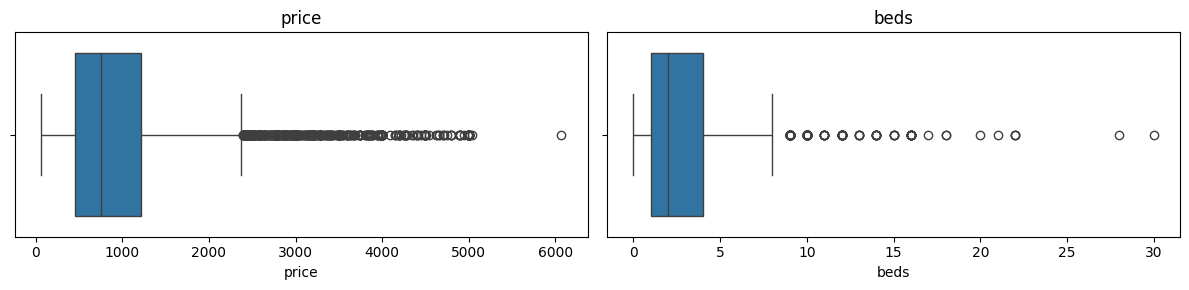

In [35]:
# Validacion visual de dos variables representativas (los outliers se mantienen)
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
sns.boxplot(x=df_clean['price'], ax=axes[0]); axes[0].set_title('price')
sns.boxplot(x=df_clean['beds'].astype('float'), ax=axes[1]); axes[1].set_title('beds')
plt.tight_layout(); plt.show()

## 5. Estandarización de formatos

- Se eliminan espacios sobrantes en los campos de texto.
- `price` → se renombra a **`price_€`** y se mantiene como numérico.
- **Aviso de codificación:** varios textos (`name`, `neighbourhood_name`, `description`) contienen el carácter de reemplazo `�` en lugar de acentos, perdidos al volcar los datos a MySQL (p. ej. `Cadaqu�s` → *Cadaqués*). **No es recuperable** a nivel de string. Se documenta como limitación de origen y se deja el texto tal cual; si se quisiera corregir habría que construir un diccionario manual en *Transformation*.

In [44]:
# Espacios sobrantes en columnas de texto
text_cols = df_clean.select_dtypes(include=['object']).columns
for col in text_cols:
    df_clean[col] = df_clean[col].str.strip()

# price -> price_€ (se mantiene numerico)
df_clean = df_clean.rename(columns={'price': 'price_€'})
print("Columna de precio:", [c for c in df_clean.columns if 'price' in c], "| dtype:", df_clean['price_€'].dtype)

# Columna `city` pasa a ser mayuscula la primera letra
df_clean["city"] = df_clean["city"].str.strip().str.capitalize()

print("columna City cambiada: ", df_clean['city'])


Columna de precio: ['price_€'] | dtype: float64
columna City cambiada:  0       Barcelona
1       Barcelona
2       Barcelona
3       Barcelona
4       Barcelona
          ...    
7688       Malaga
7689       Girona
7690      Sevilla
7691      Sevilla
7692       Malaga
Name: city, Length: 7693, dtype: object


In [45]:
# Cuantificacion del problema de codificacion (informativo, no se altera el dato)
mojibake_cols = ['name', 'neighbourhood_name', 'description']
for col in mojibake_cols:
    n = df_clean[col].fillna('').str.contains('�').sum()
    print(f"{col:20s}: {n} registros con '�' (acento perdido en origen)")

name                : 1569 registros con '�' (acento perdido en origen)
neighbourhood_name  : 1681 registros con '�' (acento perdido en origen)
description         : 5269 registros con '�' (acento perdido en origen)


## 6. Verificación final y exportación a CSV

Se genera un **único CSV** con el resultado de la limpieza, listo para la fase de *Data Transformation*.

In [48]:
print("Dimensiones finales:", df_clean.shape)
print("apartment_id unico :", df_clean['apartment_id'].is_unique)
print("Filas duplicadas   :", df_clean.duplicated().sum())
print("\nTipos de datos finales:")
df_clean.info()

Dimensiones finales: (7693, 35)
apartment_id unico : True
Filas duplicadas   : 0

Tipos de datos finales:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7693 entries, 0 to 7692
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   apartment_id                 7693 non-null   int64         
 1   name                         7690 non-null   object        
 2   description                  7643 non-null   object        
 3   host_id                      7693 non-null   int64         
 4   neighbourhood_name           7693 non-null   object        
 5   neighbourhood_district       4669 non-null   object        
 6   room_type                    7693 non-null   object        
 7   accommodates                 7693 non-null   int64         
 8   bathrooms                    7652 non-null   Int64         
 9   bedrooms                     7654 non-null   Int64         
 10  be

In [49]:
# Exportacion del CSV final (una sola tabla limpia) para Data Transformation
output_dir = Path('..') / 'Data'
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / 'clean_dataset_06_07_2026.csv'

# utf-8 (sin BOM) para un round-trip limpio con pandas en la fase siguiente
df_clean.to_csv(output_path, index=False, encoding='utf-8')

print("CSV limpio guardado en:", output_path.resolve())
print("Filas x columnas:", df_clean.shape)

CSV limpio guardado en: C:\Users\lacal\Desktop\IT_ACADEMY\simulador\ProjecteData\Equip_34\Data\clean_dataset_06_07_2026.csv
Filas x columnas: (7693, 35)
